In [9]:
using Revise
push!(LOAD_PATH, pwd()) # put current directory on path
using CooperativeHuntingPkg
using UnPack, Plots, LaTeXStrings, Measures, DifferentialEquations
using ForwardDiff, LinearAlgebra
default(
    guidefontsize=18,   # controls xlabel, ylabel, title font size
    tickfontsize=12,    # controls axis number labels
    legendfontsize=16,  # controls legend font
    linewidth=3,        # controls default line thickness
    grid = false,        # turns off grid in background
    dpi=600,
    fontfamily="Computer Modern" # font family that matches latex
)


# saving with bif diagrams
bif_fig_path = "../../CH_manuscript/FIgures/BifurcationDiagrams/"
final_fig_path = "../../CH_manuscript/"
param_label_dic = Dict(
    :mass_ratio => L"Benefit Ratio, $b_1/b_2$",
    :s1         => L"Critical group size, $s$",
    :α1_of_1 => L"Capture Prob. of Solitaries, $\alpha_1(1)$"
)
using Measures

# Simplified Cooperative Hunting Fecundity
for $A_1 = b_a a_1 M_1$, $M_2 = 0$, h_1(x) = 0$, we have
$$
W(x) = A_1 \alpha_1(x) /x
$$


In [2]:
params_base_simple = Dict{Symbol,Any}(
    :α1_of_1  => 0.05,    # capture prob of big prey by singleton
    :s1       => 2.0,     # group size where α1(x) = 0.5
    :a1       => 1.0,     # attack rate on big prey
    # no handling time
    :h1a      => 0.0,     # group-size-independent handling time, big prey
    :h2a      => 0.0,     # group-size-independent handling time, small prey
    :h2b      => 0.0,     # solo handling time (group-splittable) for small prey
    # use mass ratio as A1
    :mass_ratio => 1.0,   # m1/m2 = b1/b2; b1 and h1b derived from this
    :M1       => 1.0,    # big prey population density
    :M2       => 0.0,     # small prey population density
    :d        => 20.0,   # steepness of join/leave best-response function
    :x_max    => 21,
    :P        => 21.0,
    :Tg       => 0.01,
    # unnecessary below
    :α2_of_1  => 1.0,    # capture prob of small prey (constant)
    :a2       => 0.5,     # attack rate on small prey
    :b2       => 1.0,     # conversion rate for small prey

)
# Derive b1 and h1b at the default mass_ratio
scale_parameters_orig(params_base_simple)

Dict{Symbol, Any} with 18 entries:
  :α1_of_1    => 0.05
  :Tg         => 0.01
  :a2         => 0.5
  :d          => 20.0
  :b2         => 1.0
  :s1         => 2.0
  :mass_ratio => 1.0
  :h1b        => 0.0
  :P          => 21.0
  :M1         => 1.0
  :h2b        => 0.0
  :x_max      => 21
  :α2_of_1    => 1.0
  :h1a        => 0.0
  :h2a        => 0.0
  :M2         => 0.0
  :b1         => 1.0
  :a1         => 1.0

# Change A

In [ ]:
x = collect(1.0:1.0:20.0)
@unpack M1, M2 = params_base_simple

A1_list = [0.3, 1.5, 3.0]
params = deepcopy(params_base_simple)

fig = plot()
for (i, A1) in enumerate(A1_list)
    params[:mass_ratio] = A1
    scale_parameters_orig(params)
    W = fun_W_orig(x, M1, M2, params)
    Wabove = W[W .> W[1]]
    x_end_above = findlast(>(W[1]),W)
    plot!(
        1:x_end_above, W[1:x_end_above], 
        color = i, marker = :circle,
        label = L"$B_1 = %$A1$")
    plot!(
        x[x_end_above:end],W[x_end_above:end], 
        color = i, marker = :circle, linestyle = :dot,
        label = "")
    #plot!(x,W, color = i, marker = :circle, label = L"$B_1 = %$A1$")


end
plot!(ylim=[0.0,1.0])
plot!(xlab = "\n"*L"Group Size, $x$")
plot!(ylab = "W, per-capita fecundity")
#plot!(title = L"s_1 = 2.0, \alpha_1(1) = 0.05")
#savefig(fig, bif_fig_path*"simpleW_vs_A1.pdf")
savefig(fig, final_fig_path*"simpleW_vs_A1.pdf")
fig

In [ ]:
paramkey = :mass_ratio
paramvec = collect(0.5:0.04:5.0)

hm_A, λ_A = make_hm_versus_param_solve_g(paramkey, paramvec, params_base_simple)
plot!(legend=(0.15,0.7))
hm_A.subplots[1][:annotations] = []
plot!(xlabel = L"Total Benefit of Prey, $B_1$")
#savefig(hm_A, bif_fig_path*"equilibria_only_groups_simple_vs_A1.pdf")
savefig(hm_A, final_fig_path*"equilibria_only_groups_simple_vs_A1.pdf")

display(hm_A)


In [5]:
print(sum(λ_A .> 0))

0

# Change s

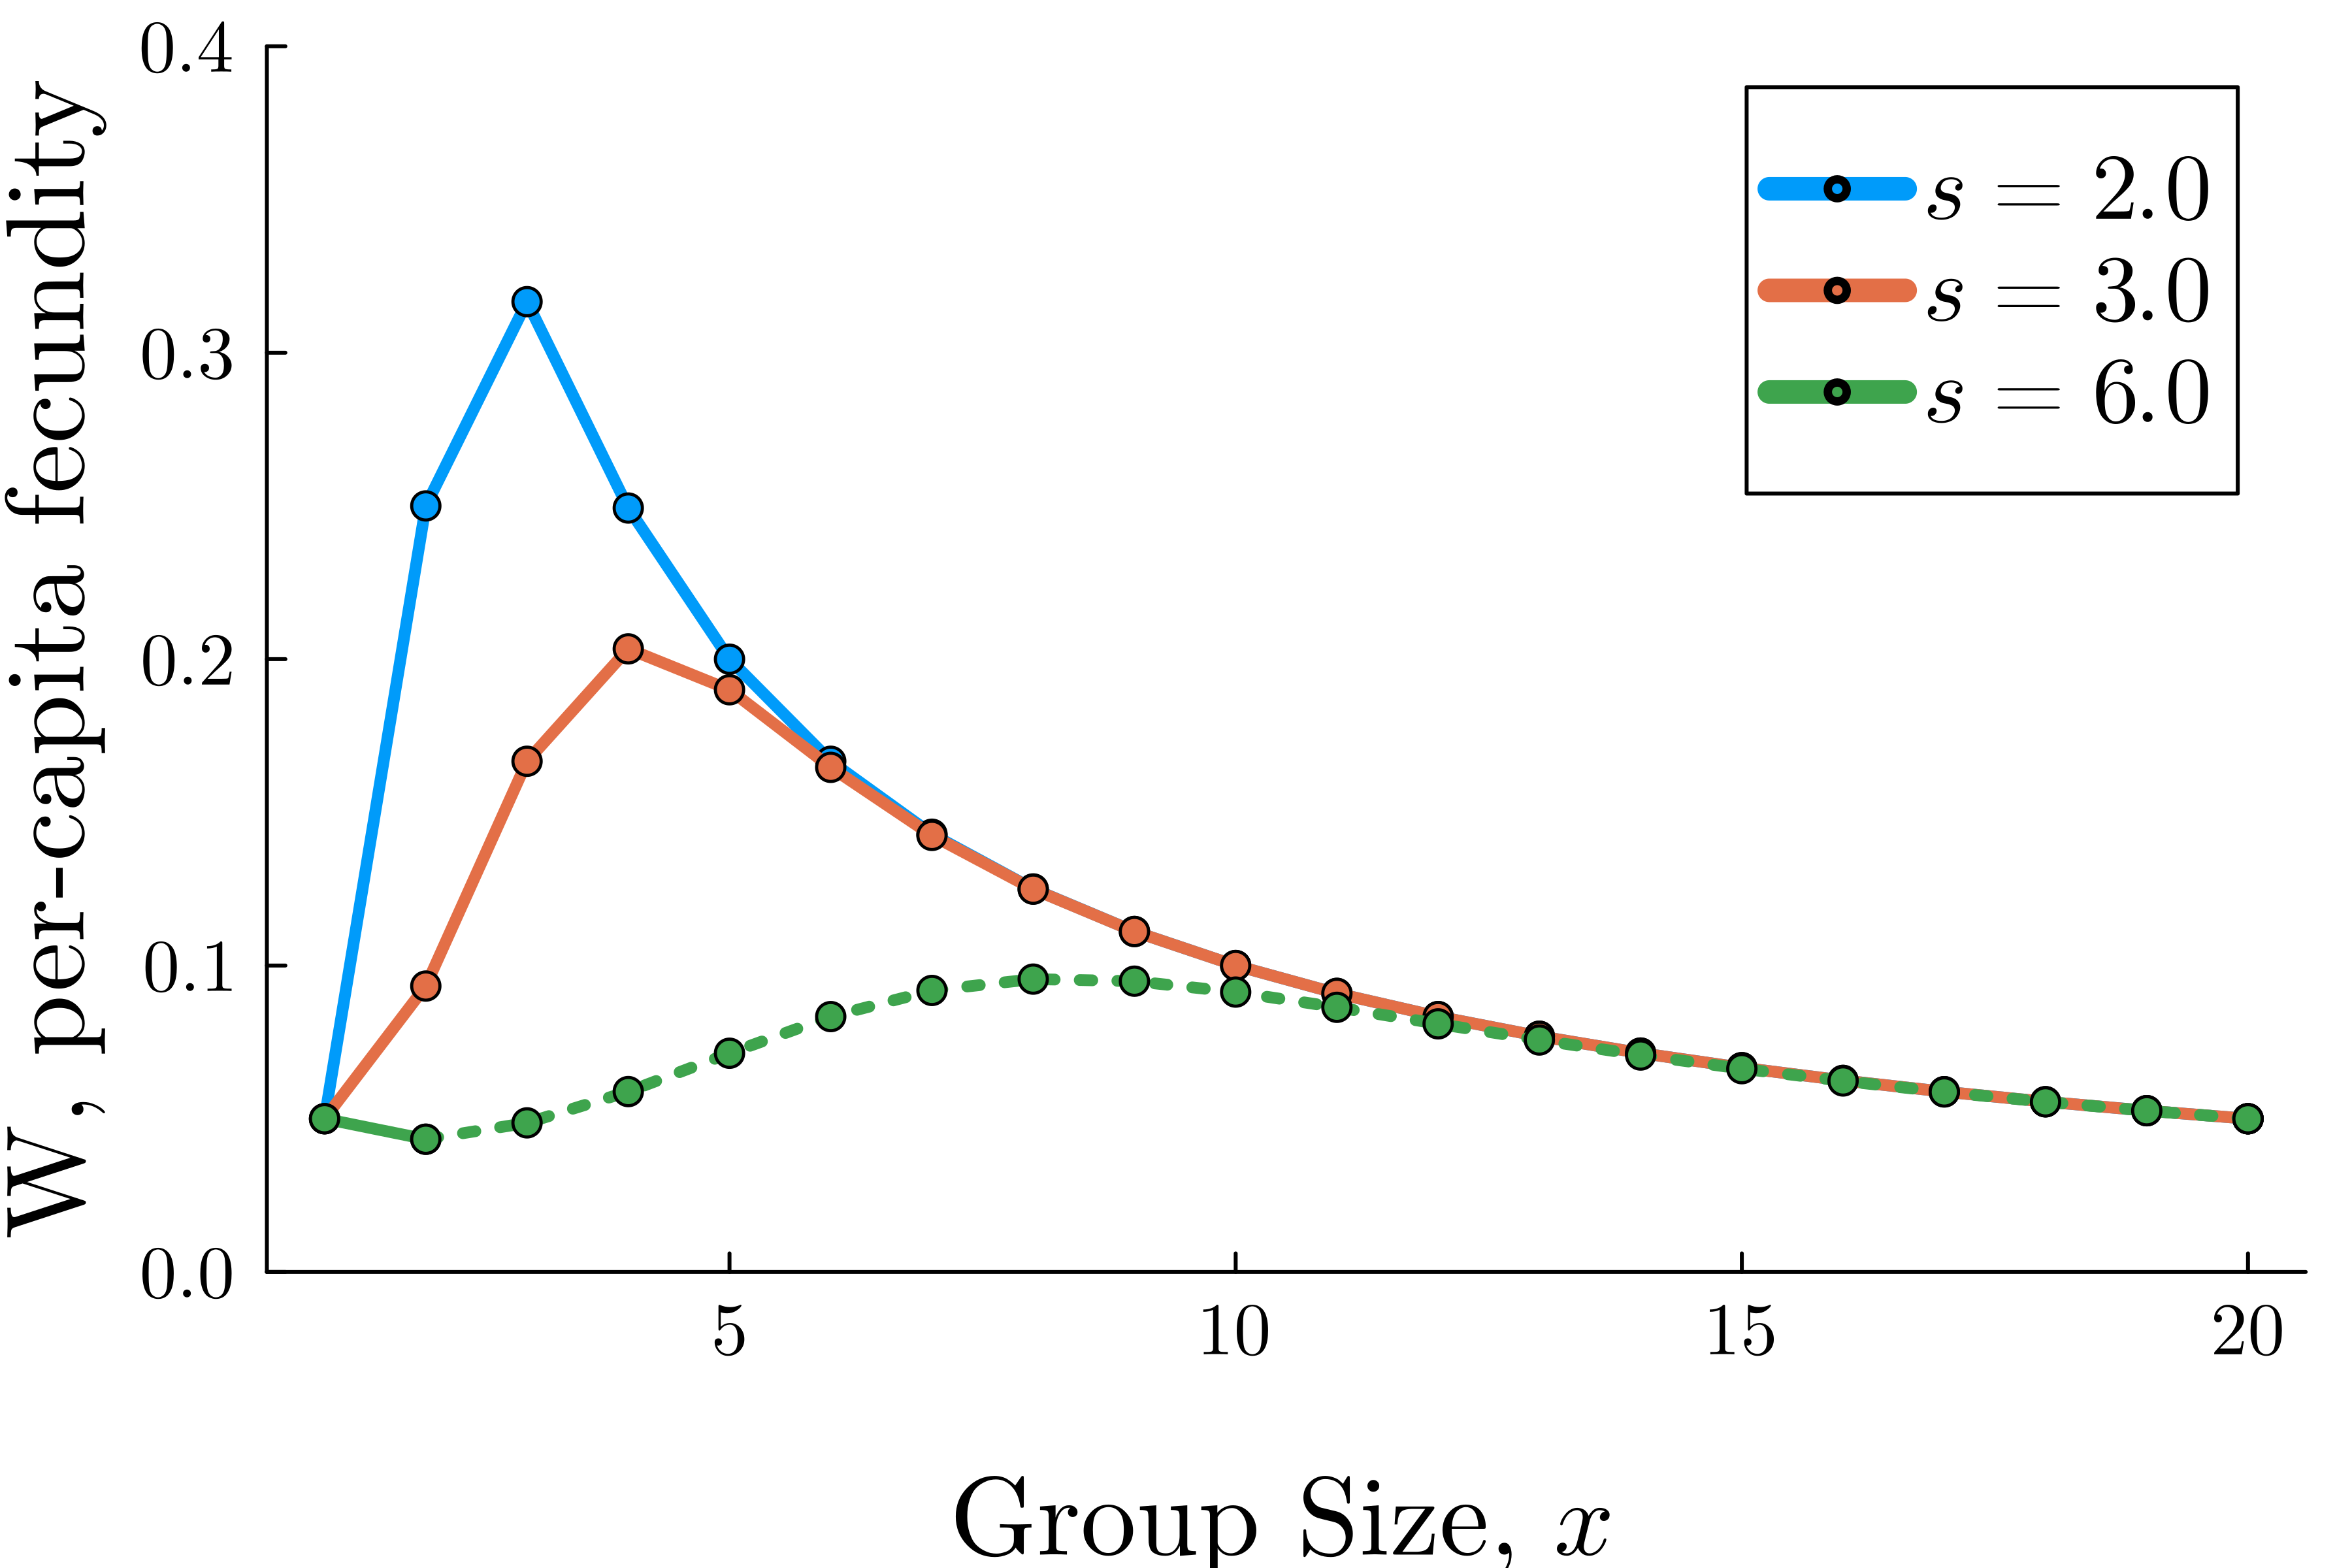

In [6]:
x = collect(1.0:1.0:20.0)
@unpack M1, M2 = params_base_simple
params = deepcopy(params_base_simple)

s_list = [2.0, 3.0, 6.0]
fig = plot()
for (i, s) in enumerate(s_list)
    params[:s1] = s
    W = fun_W_orig(x, M1, M2, params)
    #plot!(x,W, color = i, marker = :circle, label = L"$s = %$s$")
    Wabove = W[W .> W[1]]
    x_end_above = findfirst(<(W[1]),W)
    plot!(
        1:x_end_above, W[1:x_end_above], 
        color = i, marker = :circle,
        label = L"$s = %$s$")
    plot!(
        x[x_end_above:end],W[x_end_above:end], 
        color = i, marker = :circle, linestyle = :dot,
        label = "")


end
plot!(ylim=[0.0,0.4])
plot!(xlab = "\n"*L"Group Size, $x$")
plot!(ylab = "W, per-capita fecundity")
#plot!(title = L"A_1 = 3.0, \alpha_1(1)=0.05")
savefig(fig, bif_fig_path*"W_simpleW_vs_s.pdf")
fig

In [ ]:
paramkey = :s1
paramvec = collect(1.5:0.04:6.0)
hm_s, λ_s = make_hm_versus_param_solve_g(paramkey, paramvec, params_base_simple)
plot!(legend=(0.15,0.7))
plot!(xlabel=L"Critical Group Size, $s$")
hm_s.subplots[1][:annotations] = []
savefig(hm_s, bif_fig_path*"equilibria_simpleW_vs_s.pdf")
savefig(hm_s, final_fig_path*"equilibria_simpleW_vs_s.pdf")

display(hm_s)


In [8]:
print(sum(λ_s .> 0))

0

# vs $\alpha_1(1)$

In [12]:
params[:α1_of_1]

0.05

In [ ]:
x = collect(1.0:1.0:20.0)
@unpack M1, M2 = params_base_simple
params = deepcopy(params_base_simple)

α1_of_1list = [0.05, 0.15, 0.3]
fig = plot()
for (i, α1_of_1) in enumerate(α1_of_1list)
    params[:α1_of_1] = α1_of_1
    W = fun_W_orig(x, M1, M2, params)
    #plot!(x,W, color = i, marker = :circle, label = L"$s = %$s$")
    Wabove = W[W .> W[1]]
    x_end_above = findlast(>(W[1]),W)

    print(x_end_above)
    if x_end_above != nothing
        plot!(
            1:x_end_above, W[1:x_end_above], 
            color = i, marker = :circle,
            label = L"$\alpha_1(1) = %$α1_of_1$")
        plot!(
            x[x_end_above:end],W[x_end_above:end], 
            color = i, marker = :circle, linestyle = :dot,
            label = "")
    else
        print(W)
        plot!(x, W,color = i, marker = :circle, linestyle = :dot,
            label = "")
        plot!([],[],color = i, marker = :circle,
            label = L"$\alpha_1(1) = %$α1_of_1$")
    end


end
plot!(ylim=[0.0,0.4])
plot!(xlab = "\n"*L"Group Size, $x$")
plot!(ylab = "W, per-capita fecundity")
#plot!(title = L"A_1 = 3.0, \alpha_1(1)=0.05")
savefig(fig, bif_fig_path*"W_simpleW_vs_alpha.pdf")
fig

196

In [ ]:
paramkey = :α1_of_1
paramvec = collect(0.001:0.01:0.3)
hm_α, λ_α = make_hm_versus_param_solve_g(paramkey, paramvec, params_base_simple)
plot!(legend=(0.55,0.75))
hm_α.subplots[1][:annotations] = []
savefig(hm_α, bif_fig_path*"equilibria_simpleW_vs_alpha.pdf")

display(hm_α)


In [15]:
print(sum(λ_α .> 0))

0